# LAB 1 : Realisation of Logic Gates and Linear Regression

Name : Sabyasachi Ghosal

Roll Number : 24PHDDI05

Referrence Material : Page no. 26-29, Artificial Neural Network by B. Yegnanarayana




#**Problem 1** : Demonstrate the realization of NAND gate, NOR gate, and XOR gate using McCulloch Pitts (MP) and Rosenblatt’s Perceptron model.

  1. Write down the truth table of the logic gates.
  2. For MP model: compute the appropriate weight, such that the neuron provide logic
  gate output.
  3. For Perceptron: use truth table values as input and output to learn the weights
  through weight update equation.

##Write down the Objectives, Hypothesis and Experimental description for the above problem

## Objectives of MP Model & Perceptron Model
- To understand that how the linearly separability of the data can impact the modeling using a single layer perceptron and what is the bahavior
- How learning is incorporated in the Rosenblatt's perceptron model which is not present in the MP neuron. In MP neuron weights are fixed at the start.

## Hypothesis
- In the MP model, it can infer simple logic gates like (NAND, NOR) through appropriately set weights and thresholds, but it may struggle with non-linearly separable problems like XOR. 
- The Perceptron model, with iterative learning, can successfully realize NAND and NOR gates, and should fail or struggle with the XOR gate due to the non-linearity of the XOR function. The weight update mechanism in the Perceptron model will converge to a solution for linearly separable problems, leading to correct implementation of the logic gate.

## Experimenatal Description 
### MP Model
- The MP model operates with fixed weights and a threshold. These parameters are set manually based on the logic functions we are trying to realize.  For example, example weights of [-1, 1] helped to converhge NAND
- The MP model does not have a built-in learning mechanism to update weights based on the error in output. This means that if the problem is not linearly separable, such as XOR, you cannot adjust the weights to correct the outputs. Therefore, the MP neuron cannot solve the XOR problem, as it cannot create a linearly separable boundary for the XOR function.
- Here XOR is represented as y = (x1 * x2!) + (x1! * x2). Using this 2 levels combination of logic functions we will be able to get the results of XOR. Thus each neuron can only interpret small functions. When we create complex logic functions then the lines are more than 1, which can help in identifying the non-linear data.


### Rosenblatts Models
- Unlike the MP neuron, the Perceptron model has a learning mechanism where weights are adjusted iteratively based on the error between the predicted output and the actual output. 
- In problems like NAND and NOR, the Perceptron will adjust its weights over time to reduce the error. Since these problems are linearly separable, the Perceptron can eventually find a set of weights that perfectly separates the classes, allowing it to converge. Here these are weights which are changed over iterations. For example, the initial weights for NAND is [-2.4, 2.7] and the weights are convergence is [ 1.4, -1.4].
- In the case of XOR, the Perceptron will still try to adjust the weights based on the error. However, because the classes cannot be separated by a single linear boundary, the weight updates will never lead to a perfect solution. The Perceptron might oscillate, making small adjustments but never converging to a set of weights that solves the XOR problem. The weight update mechanism helps it to "try" and adjust, but because the problem is non-linear, the model ultimately fails to find a satisfactory solution.

## 1. Truth Table for logic gates

| A | B | AND | OR  | NAND | NOR | XOR |
|---|---|-----|-----|------|-----|-----|
| 0 | 0 |  0  |  0  |  1   |  1  |  0  |
| 0 | 1 |  0  |  1  |  1   |  0  |  1  |
| 1 | 0 |  0  |  1  |  1   |  0  |  1  |
| 1 | 1 |  1  |  1  |  0   |  0  |  0  |



**MP neuron**
- Activation value, $x = \sum \limits _{i=1} ^{M} w_{i}a_{i} - \theta $
- Output signal, $s = f(x) $


**Perceptron**
- Activation value, $x = \sum \limits _{i=1} ^{M} w_{i}a_{i} - \theta$
- Output signal, $s = f(x) $
- Error, $ \delta = b - s $, where b is the desired output
- Weight change, $ \Delta w_{i} = \eta \delta a_{i} $, where $\eta$ is learning parameter

==============================

## Programming :
  Please write a program to demonstrate the same

In [1]:
## Part A : MP model

import torch
import numpy as np
import matplotlib.pyplot as plt


def mp_model(x,gate):

  ## Write the activation function and define weights and bias for all three gates

  if gate == "NAND":
    ## Write your code here
    weights = np.array([-1, -1]).reshape(2,1)
    threshold = -1
    res = np.matmul(weights.T, x) 
    out = 1 if res >= threshold else 0
  if gate == "NOR":
    
    ## Write your code here
    weights = np.array([1, 1]).reshape(2,1)
    threshold = 0
    res = np.matmul(weights.T, x) 
    #print (weights, res)
    out = 1 if res <= threshold else 0

  if gate == "XOR":
    
    ## Write your code here
    weights = np.array([1, -1]).reshape(2,1)
    threshold = 1
    res = np.matmul(weights.T, x) 
    #print (weights, res)
    out1 = 1 if res >= threshold else 0

    weights = np.array([-1, 1]).reshape(2,1)
    threshold = 1
    res = np.matmul(weights.T, x) 
    #print (weights, res)
    out2 = 1 if res >= threshold else 0

    weights = np.array([1, 1]).reshape(2,1)
    z = np.array([out1, out2]).reshape(2,1)
    threshold = 1
    res = np.matmul(weights.T, z) 
    #print (weights, res)
    out = 1 if res >= threshold else 0
  return out


inp_list =  [[0,0], [0,1], [1,0], [1,1]]## Create a list consisting of inputs to logic gates (Binary, i.e (0,0),(0,1),(1,0),(1,1))
req_gates = ["NAND","NOR","XOR"] #list("NAND","NOR","XOR") ## Create a list of all gates (NAND,NOR,XOR)

for gate in req_gates:
  print('Results for ' + gate + ' gate : ')
  for inp in inp_list:
    print("Input is : " + str(inp))
    out = mp_model(inp,gate)
    print("Logic Gate output is : ",out)

  print('=====================================')

Results for NAND gate : 
Input is : [0, 0]
Logic Gate output is :  1
Input is : [0, 1]
Logic Gate output is :  1
Input is : [1, 0]
Logic Gate output is :  1
Input is : [1, 1]
Logic Gate output is :  0
Results for NOR gate : 
Input is : [0, 0]
Logic Gate output is :  1
Input is : [0, 1]
Logic Gate output is :  0
Input is : [1, 0]
Logic Gate output is :  0
Input is : [1, 1]
Logic Gate output is :  0
Results for XOR gate : 
Input is : [0, 0]
Logic Gate output is :  0
Input is : [0, 1]
Logic Gate output is :  1
Input is : [1, 0]
Logic Gate output is :  1
Input is : [1, 1]
Logic Gate output is :  0


Weights for NAND : 
[[ 1.4]
 [-1.4]
 [-0.1]]
Weights for NOR : 
[[ 2.77555756e-17]
 [-2.60000000e+00]
 [-1.08246745e-15]]
Weights for XOR : 
[[ 2.77555756e-17]
 [-3.00000000e-01]
 [ 1.00000000e-01]]


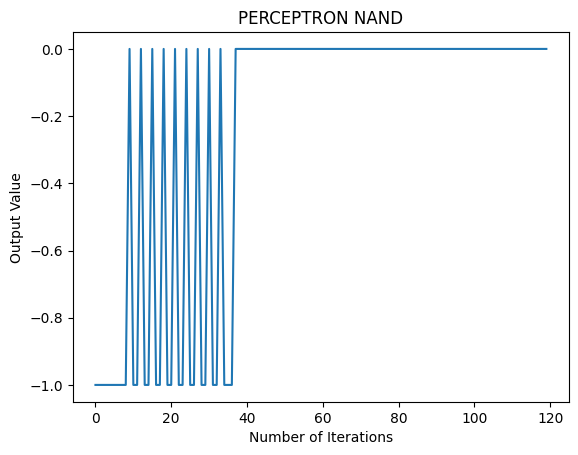

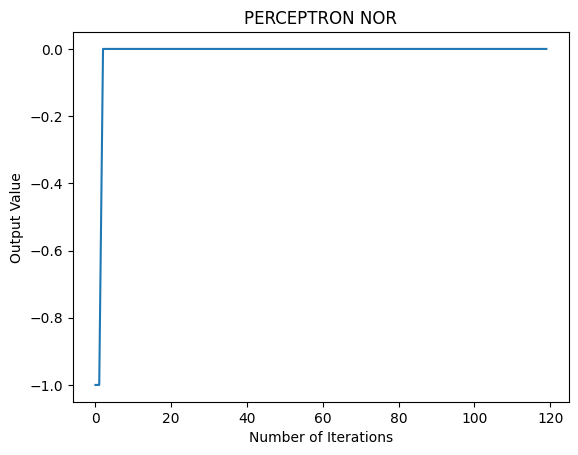

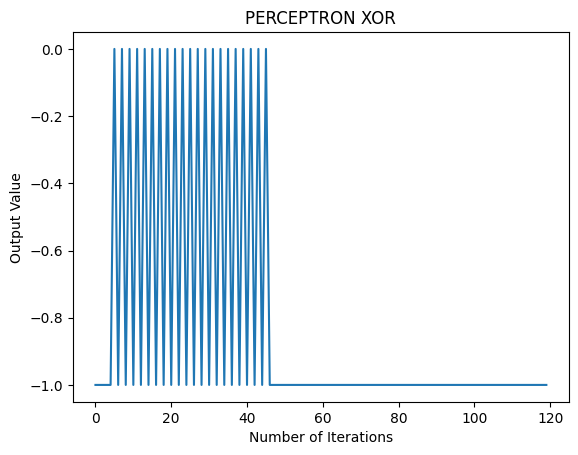

In [2]:
## Part B : Rosenblatt's Percept

import numpy as np
import matplotlib.pyplot as plt

def rosenblatt_perceptron(inp_list,y_true,learning_rate,w_init,num_epochs,gate):

  error = []
    
  for epoch in range(num_epochs):
    ## Write the learning code here,
    for index, input_vector in enumerate(inp_list):
      #print("input_vector", input_vector)
      input_vector = np.array(input_vector).reshape(len(input_vector), 1)
            
      activation = np.dot(w_init.T, input_vector)[0]
      #print("activation", activation)
      y_pred = 1. if activation >= 0 else 0.
      error_value = y_true[index] - y_pred
      
      
      # print(w_init)
      # print(learning_rate)
      # print(error_value)
      # print(input_vector)
      # print(type(input_vector))
      # print("========")
      w_new = w_init + learning_rate * error_value * input_vector
      #print(w_init, w_new)
      w_init = w_new
    

    
    ## return new weights and error,
    ## Save the error value after each iteration to plot a error v/s iteration graph in case of all 3 gates
    error.append(error_value)
  return w_new,error

inp_list = [[0.,0.], [0.0,1.], [1.,0.], [1.,1.]]## Create a list consisting of inputs to logic gates (Binary, i.e (0,0),(0,1),(1,0),(1,1))
#print ([mp_model(inp, "NAND") for inp in inp_list])
nand_output = [mp_model(inp, "NAND") for inp in inp_list]  ## Define NAND gate target output
nor_output = [mp_model(inp, "NOR") for inp in inp_list] ## Define NOR gate target output
xor_output = [mp_model(inp, "XOR") for inp in inp_list] ## Define XOR gate target output

learning_rate = 0.1 ## Define a learning rate
w_initial = np.array([-2.4, 2.7]).reshape(2,1)## Initialise weights
num_epochs = 120 ## Set number of epochs

# Add bias term (1) to the input vectors
inp_list = np.hstack((np.ones((len(inp_list), 1)), inp_list))
#print (inp_list)

# Initialize weights with bias weight
w_initial = np.vstack(([0.4], w_initial))  # Adjust if initial weights include bias
#print(w_initial)

## For NAND gate
w_new1,error1 = rosenblatt_perceptron(inp_list,nand_output,learning_rate,w_initial,num_epochs,"NAND")

## For NOR gate
w_new2,error2 = rosenblatt_perceptron(inp_list,nor_output,learning_rate,w_initial,num_epochs,"NOR")

## For XOR gate
w_new3,error3 = rosenblatt_perceptron(inp_list,xor_output,learning_rate,w_initial,num_epochs,"XOR")

fig1, ax1 = plt.subplots()
ax1.plot(error1)
ax1.set_title('PERCEPTRON NAND')
ax1.set_xlabel('Number of Iterations')
ax1.set_ylabel('Output Value')
print("Weights for NAND : ")
print(w_new1)

fig2, ax2 = plt.subplots()
ax2.plot(error2)
ax2.set_title('PERCEPTRON NOR')
ax2.set_xlabel('Number of Iterations')
ax2.set_ylabel('Output Value')
print("Weights for NOR : ")
print(w_new2)

fig3,ax3 = plt.subplots()
ax3.plot(error3)
ax3.set_title('PERCEPTRON XOR')
ax3.set_xlabel('Number of Iterations')
ax3.set_ylabel('Output Value')
print("Weights for XOR : ")
print(w_new3)

## Inferences and Conclusion : State all the key observations and conclusion

- The McCulloch-Pitts model cannot solve XOR because it lacks a learning mechanism to adjust weights dynamically also XOR is not linearly seprable data.
- Rosenblatt's Perceptron also fails to converge on XOR because XOR is non-linearly separable, but the weight update mechanism in the Perceptron model allows it to learn from its mistakes. This iterative learning is crucial for understanding the limitations of single-layer networks and the need for more complex models like multi-layer Perceptrons to handle non-linear problems like XOR.
- Using a two-level logic gate structure with MP neurons allows to effectively solve the XOR problem by breaking it down into smaller, linearly separable components. Each MP neuron handles a part of the function, and by combining these outputs, achieve the non-linear XOR function. This approach illustrates how complex functions can be realized by combining simpler, linear functions in a structured way.

# **Problem 2** : Demonstrate the realization of $y = 1 + 2x_{1} + 2x_{2}$ using Widrow’s Adaline model.

  1. Generate some N no. of data points using equation $y = 1 + 2x_{1} + 2x_{2}$.
  2. Use the input and output data to train the Adaline model, after training the Adaline
  model should provide appropriate y as output value for any arbitrary input.

## Write down the Objectives, Hypothesis and Experimental description for the above problem

The difference between Rosenblatts model and Adaline is that in the Adaline the analog activation value (x) is compared with the target output (b). Thus the output is a linear function of the activation value (x).

## Objectives
-  The goal is to show that the Adaline model can be trained to accuractely predict the output of the equation y = 1 + 2x1 + 2x2. This is because Adapaline is suppossed to work for this equation as this is a linear equation. It is to test that if convergence is possible with this linear equation. Also the goal is to understand the weight updates and how the learning rate affects the convergence. Also the wight updates should minimise the mean square error.

## Hypothesis
- The linear equation  y = 1 + 2x1 + 2x2. Here the output is same as the activation function
- Set of data points to train and test the model with random x1 and x2 value.
- Learning rate should be small << 1

## Experimental Description
- The training set generates set of data for x1 and x2. 
- Then a random set of weights are initialised. The model will learn the correct weights after convergence.
- The output is same as the activation function.
- The error is calculated after every iteration. This error is Least Mean Square Error.
- The weights will be initialised to random weights and the updates should reduce the Least Mean Square error and should converge to set of weights which will not change much with iterations 




## Programming :
  Please write a program to demonstrate the same

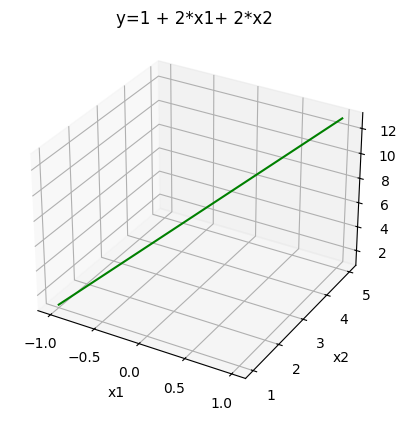

In [3]:
import random
import torch
import matplotlib.pyplot as plt

n = 100
x1 = torch.linspace(-1,1,n) # Input Generation
x2 = torch.linspace(1,5,n) # Input Generation

y_true = torch.add(1,torch.add(2*x1,2*x2)) # True Output

plt.figure()
ax = plt.axes(projection = '3d')
ax.plot3D(x1, x2, y_true, 'green')
plt.title('y=1 + 2*x1+ 2*x2')
plt.xlabel('x1')
plt.ylabel('x2')

plt.show()

x-size torch.Size([3, 100])
y_true torch.Size([100])
w-size torch.Size([3, 1])
Final Weights for Learning rate - 0.001 are :- 
tensor([[0.3996],
        [0.5339],
        [2.2664]])


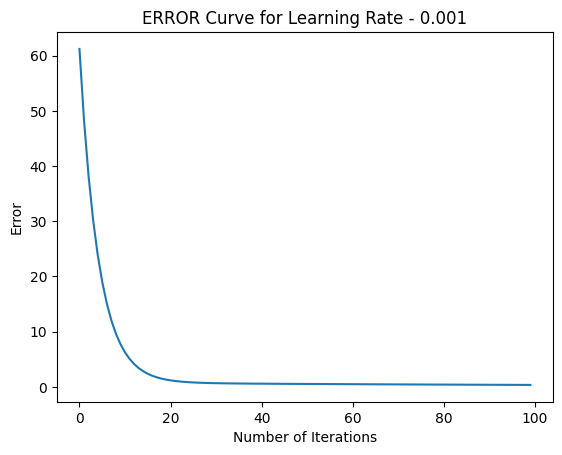

In [9]:
def adaline(lr, x1, x2, y_true):

  w = [0,0,0]

  # Converting Inputs and weights to Tensors

  ones = torch.ones(n).reshape(1,n)
  x = torch.cat([x1,x2],dim=0)
  x = torch.cat([ones,x],dim=0) # Augmenting the Input

  w = torch.tensor(w).reshape(len(w),1).float()
  print("x-size", x.shape)
  print("y_true", y_true.shape)
  print("w-size",w.shape)

  epochs = 100
  error = []

  # Training Loop

  for eps in range(epochs):
    y_pred = torch.matmul(w.T,x)
    err = y_true - y_pred
    error.append(torch.mean(err**2).item())
    delta_w = lr * torch.matmul(x,err.T)
    
    ## return new weights and error,
    ## Save the error value after each iteration to plot a error v/s iteration graph in case of all 3 gates
    w = w + delta_w
    #print("After Update", w.shape)
    w_new = w
  return error,w_new

lr1 = 0.0001
x1 = x1.reshape(1,n)
x2 = x2.reshape(1,n)
error,w_new = adaline(lr1, x1, x2, y_true)
fig,ax = plt.subplots()
ax.plot(error)
ax.set_title('ERROR Curve for Learning Rate - 0.001')
ax.set_xlabel('Number of Iterations')
ax.set_ylabel('Error')

print('Final Weights for Learning rate - 0.001 are :- ')
print(w_new)


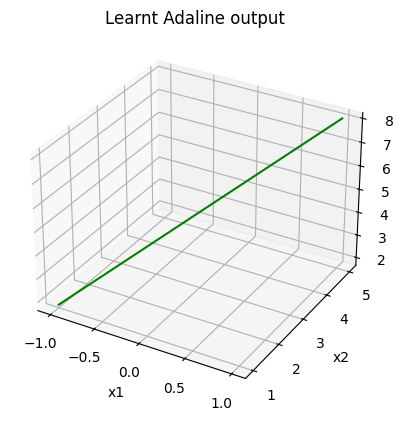

In [7]:
n = 100


ones = torch.ones(n).reshape(1,n)
x1 = x1.reshape(1,n)
x2 = x2.reshape(1,n)
x = torch.cat([x1,x2],dim=0)
x = torch.cat([ones,x],dim=0)
y_pred = torch.mm(w_new.T,x).reshape(n)


x1 = torch.linspace(-1,1,n) # Input Generation
x2 = torch.linspace(1,5,n) # Input Generation
plt.figure()
ax = plt.axes(projection = '3d')
ax.plot3D(x1, x2, y_pred, 'green')
plt.title('Learnt Adaline output')
plt.xlabel('x1')
plt.ylabel('x2')

plt.show()

## Inferences and Conclusion : State all the key observations and conclusion

=== Write your answer here ===

- Weight initialisation was done prioir to random initialisation but convergence of error happened with weight updates with iterations.
- Here learning rate is 0.001 which is kept to manage error correction and convergence
- Here the output function is assumed linear and it is speacial case of delta learning law.
- The adaline function converges to final values by repeated use of the input-output pattern pairs in this case of linear equation. But it may not work for other cases and equations.
- This is also a case of supervised learning as it required desired output for each of x1 and x2 inputs. 